val: indexed 3944 files
test: indexed 4190 files
val: processed 100/500
val: processed 200/500
val: processed 300/500
val: processed 400/500
val: processed 500/500

val done in 498.78s
missing files: 0
test: processed 100/500
test: processed 200/500
test: processed 300/500
test: processed 400/500
test: processed 500/500

test done in 466.71s
missing files: 0

--- VAL RESULTS ---
mean       AUROC: 0.7540
std        AUROC: 0.7487
l2         AUROC: 0.7232
mean_abs   AUROC: 0.7461

--- TEST RESULTS ---
mean       AUROC: 0.5771
std        AUROC: 0.7586
l2         AUROC: 0.6960
mean_abs   AUROC: 0.7417


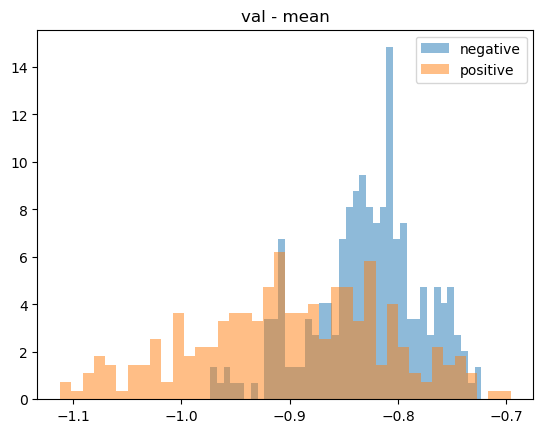

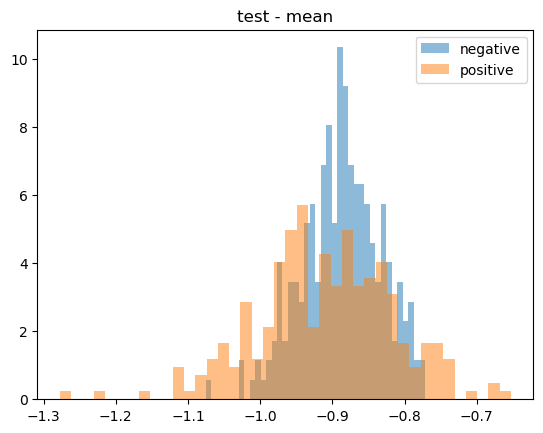

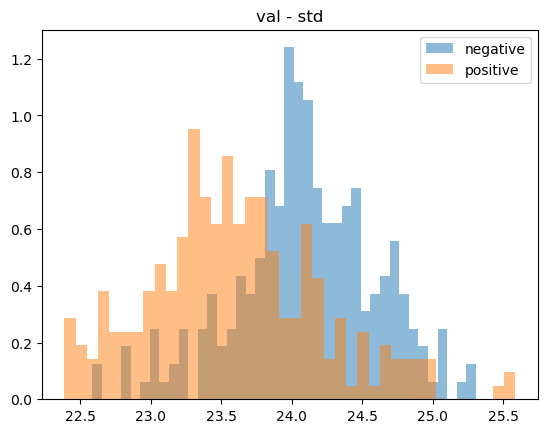

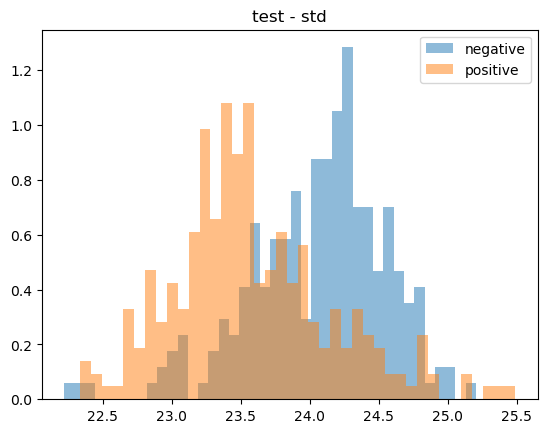

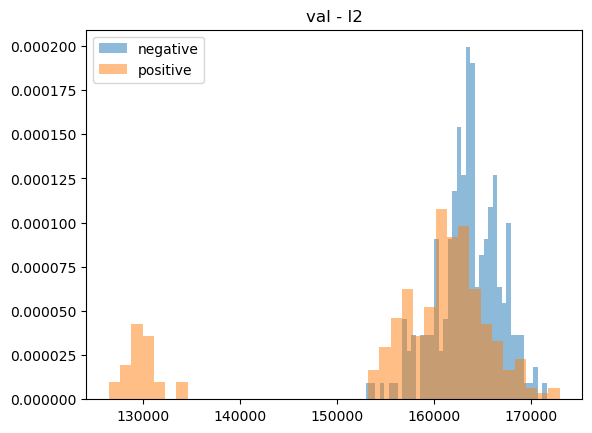

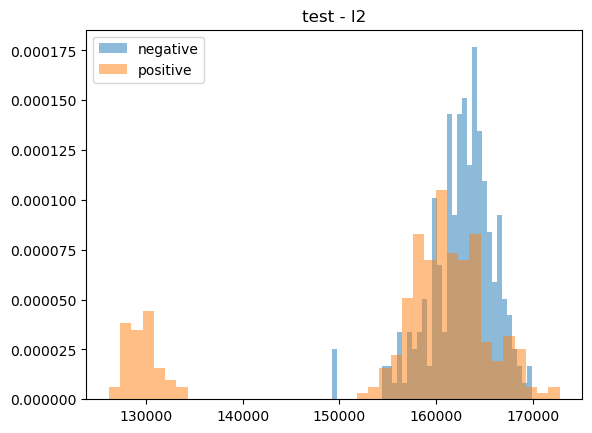

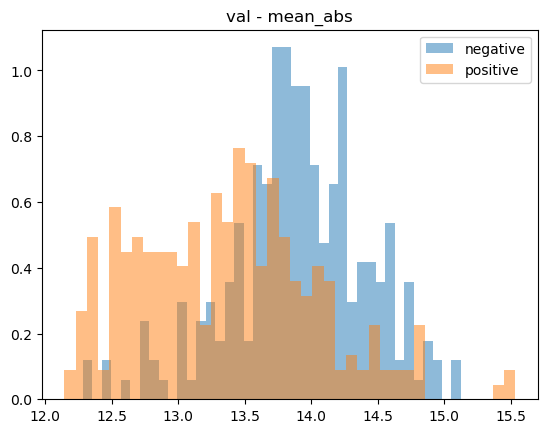

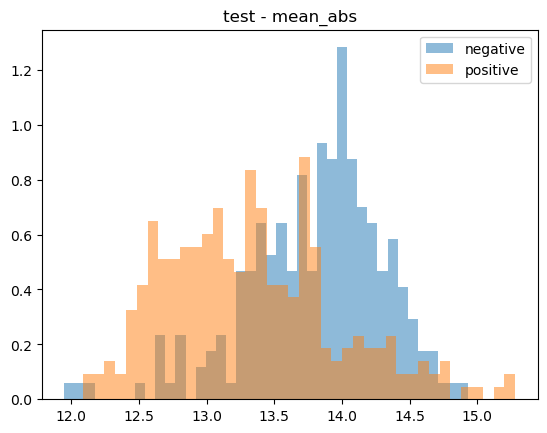

In [10]:
# ============================================================
# FAST RAW BOLTZ DIAGNOSTIC (VAL / TEST)
# ============================================================

import os
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ----------------------------
# CONFIG
# ----------------------------
VAL_CSV  = "/home/natasha/multimodal_model/data/val/val_df_clean_pos_neg.csv"
TEST_CSV = "/home/natasha/multimodal_model/data/test/test_df_clean_pos_neg.csv"
BOLTZ_OUTPUT_ROOT = Path("/home/natasha/multimodal_model/outputs")

# safety controls
MAX_SAMPLES = 500   # start small (e.g. 100–500), then increase
RANDOM_SEED = 42

# ----------------------------
# BUILD INDEX (ONE-TIME)
# ----------------------------
def build_boltz_index(split_name):
    split_dir = BOLTZ_OUTPUT_ROOT / split_name
    index = {}

    for npz_path in split_dir.glob("chunk_*/boltz_results_*/predictions/*/embeddings_*.npz"):
        pair_id = npz_path.stem.replace("embeddings_", "")
        index[pair_id] = npz_path

    print(f"{split_name}: indexed {len(index)} files")
    return index


# ----------------------------
# LOAD DATAFRAME
# ----------------------------
def load_df(csv_path):
    df = pd.read_csv(csv_path)
    df["pair_id"] = df["pair_id"].astype(str)
    df["binding_flag"] = df["binding_flag"].astype(int)
    return df[["pair_id", "binding_flag"]]


# ----------------------------
# FAST SUMMARY ONLY
# ----------------------------
def fast_summary(z):
    z = z.astype(np.float32).reshape(-1)

    return {
        "mean": float(np.mean(z)),
        "std": float(np.std(z)),
        "l2": float(np.linalg.norm(z)),
        "mean_abs": float(np.mean(np.abs(z))),
    }


# ----------------------------
# LOAD + SUMMARISE
# ----------------------------
def process_split(df, index, split_name, max_samples=None):
    if max_samples:
        df = df.sample(n=min(max_samples, len(df)), random_state=RANDOM_SEED)

    rows = []
    missing = 0

    t0 = time.time()

    for i, (_, row) in enumerate(df.iterrows()):
        pid = row["pair_id"]
        label = row["binding_flag"]

        npz_path = index.get(pid, None)
        if npz_path is None:
            missing += 1
            continue

        with np.load(npz_path) as data:
            # pick largest numeric array (fast heuristic)
            arrays = {k: data[k] for k in data.keys()}
            z = max(arrays.values(), key=lambda x: x.size)

        stats = fast_summary(z)

        rows.append({
            "binding_flag": label,
            **stats
        })

        if (i+1) % 100 == 0:
            print(f"{split_name}: processed {i+1}/{len(df)}")

    print(f"\n{split_name} done in {time.time()-t0:.2f}s")
    print(f"missing files: {missing}")

    return pd.DataFrame(rows)


# ----------------------------
# METRICS
# ----------------------------
def evaluate(df, split_name):
    y = df["binding_flag"].values

    print(f"\n--- {split_name.upper()} RESULTS ---")

    for col in ["mean", "std", "l2", "mean_abs"]:
        x = df[col].values

        if np.std(x) == 0:
            continue

        auroc = max(
            roc_auc_score(y, x),
            roc_auc_score(y, -x)
        )

        print(f"{col:10s} AUROC: {auroc:.4f}")


# ----------------------------
# PLOTS
# ----------------------------
def plot_hist(df, metric, split_name):
    pos = df[df.binding_flag == 1][metric]
    neg = df[df.binding_flag == 0][metric]

    plt.figure()
    plt.hist(neg, bins=40, density=True, alpha=0.5, label="negative")
    plt.hist(pos, bins=40, density=True, alpha=0.5, label="positive")
    plt.title(f"{split_name} - {metric}")
    plt.legend()
    plt.show()


# ============================================================
# RUN PIPELINE
# ============================================================

val_df = load_df(VAL_CSV)
test_df = load_df(TEST_CSV)

val_index = build_boltz_index("val")
test_index = build_boltz_index("test")

val_diag = process_split(val_df, val_index, "val", MAX_SAMPLES)
test_diag = process_split(test_df, test_index, "test", MAX_SAMPLES)

evaluate(val_diag, "val")
evaluate(test_diag, "test")

for metric in ["mean", "std", "l2", "mean_abs"]:
    plot_hist(val_diag, metric, "val")
    plot_hist(test_diag, metric, "test")

val: indexed 3944 files
test: indexed 4190 files
val: processed 100/500
val: processed 200/500
val: processed 300/500
val: processed 400/500
val: processed 500/500

val done in 465.74s
missing files: 0
test: processed 100/500
test: processed 200/500
test: processed 300/500
test: processed 400/500
test: processed 500/500

test done in 474.12s
missing files: 0

--- VAL RESULTS ---
mean                         AUROC: 0.7540   (lower -> positive)
std                          AUROC: 0.7487   (lower -> positive)
mean_abs                     AUROC: 0.7461   (lower -> positive)
l2                           AUROC: 0.7232   (lower -> positive)

--- TEST RESULTS ---
std                          AUROC: 0.7586   (lower -> positive)
mean_abs                     AUROC: 0.7417   (lower -> positive)
l2                           AUROC: 0.6960   (lower -> positive)
mean                         AUROC: 0.5771   (lower -> positive)

Top VAL metrics:
mean


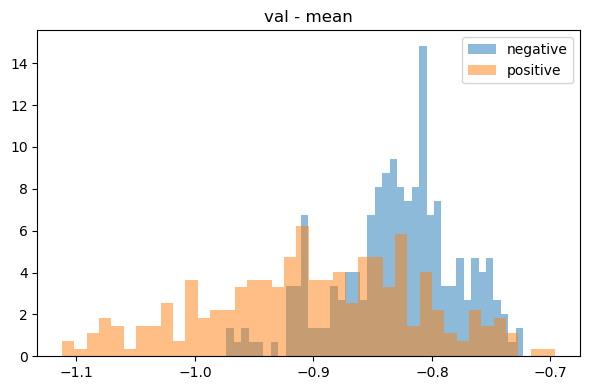

std


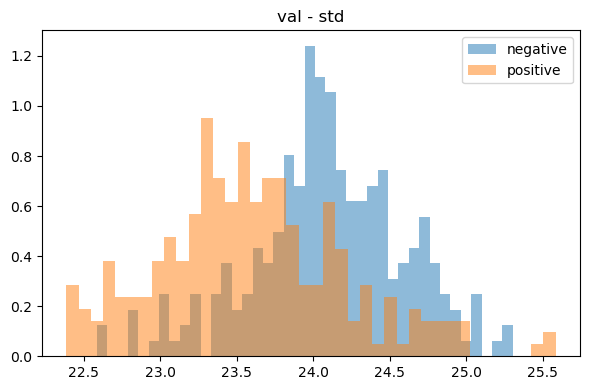

mean_abs


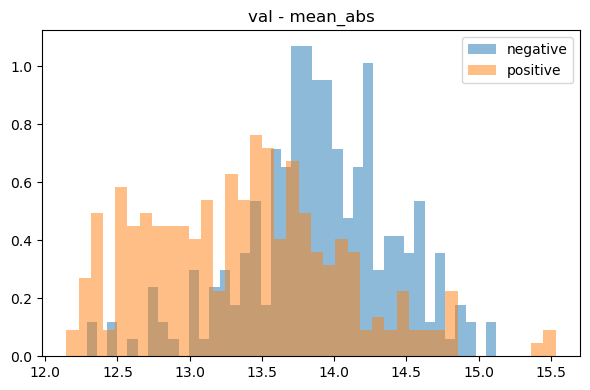

l2


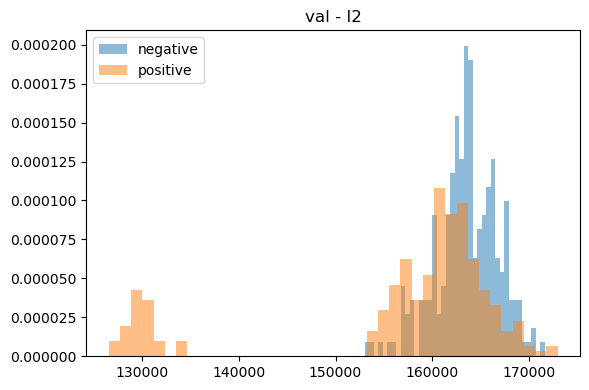


Top TEST metrics:
std


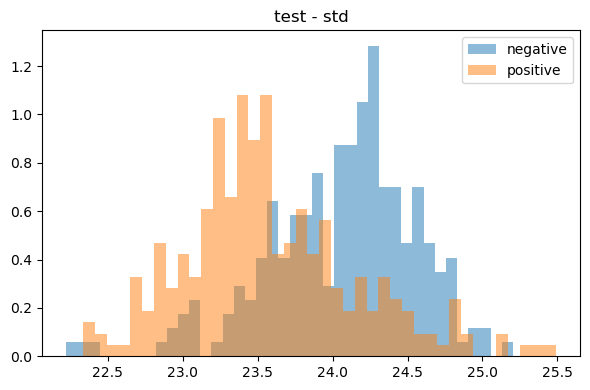

mean_abs


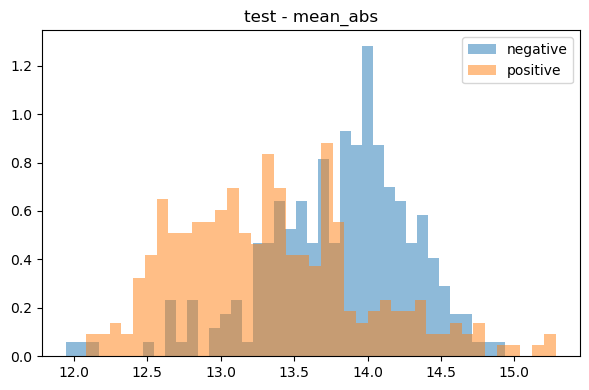

l2


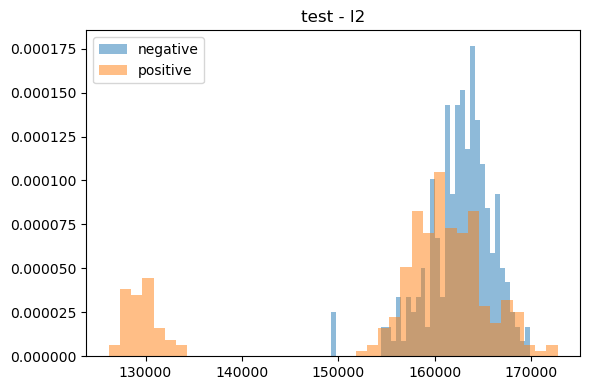

mean


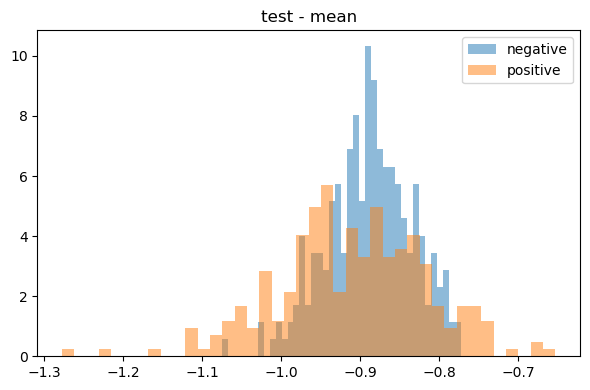

In [12]:
# Redo but now look into off-diagonals as well

# ============================================================
# FAST RAW BOLTZ DIAGNOSTIC (VAL / TEST) WITH OFF-DIAGONALS
# ============================================================

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

# ----------------------------
# CONFIG
# ----------------------------
VAL_CSV  = "/home/natasha/multimodal_model/data/val/val_df_clean_pos_neg.csv"
TEST_CSV = "/home/natasha/multimodal_model/data/test/test_df_clean_pos_neg.csv"
BOLTZ_OUTPUT_ROOT = Path("/home/natasha/multimodal_model/outputs")

MAX_SAMPLES = 500      # start at 100 or 500
RANDOM_SEED = 42
BINS = 40

# ----------------------------
# BUILD INDEX (ONE-TIME)
# ----------------------------
def build_boltz_index(split_name):
    split_dir = BOLTZ_OUTPUT_ROOT / split_name
    index = {}
    for npz_path in split_dir.glob("chunk_*/boltz_results_*/predictions/*/embeddings_*.npz"):
        pair_id = npz_path.stem.replace("embeddings_", "")
        index[pair_id] = npz_path
    print(f"{split_name}: indexed {len(index)} files")
    return index

# ----------------------------
# LOAD DATAFRAME
# ----------------------------
def load_df(csv_path):
    df = pd.read_csv(csv_path)
    df["pair_id"] = df["pair_id"].astype(str)
    df["binding_flag"] = df["binding_flag"].astype(int)
    return df[["pair_id", "binding_flag"]]

# ----------------------------
# PICK RAW ARRAY
# ----------------------------
def choose_largest_numeric_array(npz_file):
    arrays = {k: npz_file[k] for k in npz_file.files}
    numeric = {k: v for k, v in arrays.items() if np.issubdtype(v.dtype, np.number)}
    if not numeric:
        raise ValueError("No numeric arrays found in NPZ")
    key = max(numeric.keys(), key=lambda k: numeric[k].size)
    return key, numeric[key]

# ----------------------------
# FAST GLOBAL + OFF-DIAGONAL SUMMARIES
# ----------------------------
def fast_summary_with_offdiag(z):
    z = np.asarray(z, dtype=np.float32)

    # global summaries on full tensor
    flat = z.reshape(-1)
    out = {
        "mean": float(np.mean(flat)),
        "std": float(np.std(flat)),
        "l2": float(np.linalg.norm(flat)),
        "mean_abs": float(np.mean(np.abs(flat))),
    }

    # Off-diagonal logic only if first two dims are square
    if z.ndim >= 2 and z.shape[0] == z.shape[1]:
        # Collapse channels if present: (L, L, C) -> (L, L)
        # Using mean across channels as a cheap scalar projection
        if z.ndim == 3:
            z2 = np.mean(z, axis=-1)
            z2_abs = np.mean(np.abs(z), axis=-1)
        else:
            z2 = z
            z2_abs = np.abs(z)

        L = z2.shape[0]

        total_sum = float(np.sum(z2))
        diag_sum = float(np.trace(z2))
        n_off = L * L - L

        total_abs_sum = float(np.sum(z2_abs))
        diag_abs_sum = float(np.trace(z2_abs))

        diag_mean = diag_sum / max(1, L)
        offdiag_mean = (total_sum - diag_sum) / max(1, n_off)

        diag_abs_mean = diag_abs_sum / max(1, L)
        offdiag_abs_mean = (total_abs_sum - diag_abs_sum) / max(1, n_off)

        # Frobenius-style split
        total_sq_sum = float(np.sum(z2 * z2))
        diag_sq_sum = float(np.sum(np.diag(z2) ** 2))
        offdiag_sq_sum = total_sq_sum - diag_sq_sum

        diag_l2 = float(np.sqrt(max(diag_sq_sum, 0.0)))
        offdiag_l2 = float(np.sqrt(max(offdiag_sq_sum, 0.0)))

        out.update({
            "diag_mean": diag_mean,
            "offdiag_mean": offdiag_mean,
            "diag_minus_offdiag": diag_mean - offdiag_mean,
            "diag_abs_mean": diag_abs_mean,
            "offdiag_abs_mean": offdiag_abs_mean,
            "diag_abs_minus_offdiag_abs": diag_abs_mean - offdiag_abs_mean,
            "diag_l2": diag_l2,
            "offdiag_l2": offdiag_l2,
            "offdiag_energy_fraction": offdiag_sq_sum / max(total_sq_sum, 1e-12),
        })

    return out

# ----------------------------
# PROCESS SPLIT
# ----------------------------
def process_split(df, index, split_name, max_samples=None):
    if max_samples is not None:
        df = df.sample(n=min(max_samples, len(df)), random_state=RANDOM_SEED).reset_index(drop=True)

    rows = []
    missing = 0
    t0 = time.time()

    for i, row in df.iterrows():
        pid = row["pair_id"]
        label = int(row["binding_flag"])

        npz_path = index.get(pid)
        if npz_path is None:
            missing += 1
            continue

        with np.load(npz_path, allow_pickle=False) as f:
            chosen_key, z = choose_largest_numeric_array(f)

        stats = fast_summary_with_offdiag(z)
        rows.append({
            "pair_id": pid,
            "binding_flag": label,
            "chosen_key": chosen_key,
            **stats
        })

        if (i + 1) % 100 == 0:
            print(f"{split_name}: processed {i+1}/{len(df)}")

    elapsed = time.time() - t0
    print(f"\n{split_name} done in {elapsed:.2f}s")
    print(f"missing files: {missing}")

    return pd.DataFrame(rows)

# ----------------------------
# EVALUATION
# ----------------------------
def evaluate(df, split_name):
    y = df["binding_flag"].values
    metric_cols = [c for c in df.columns if c not in ["pair_id", "binding_flag", "chosen_key"]]

    print(f"\n--- {split_name.upper()} RESULTS ---")
    results = []

    for col in metric_cols:
        x = df[col].values.astype(float)
        if np.std(x) == 0:
            continue

        auroc_pos = roc_auc_score(y, x)
        auroc_neg = roc_auc_score(y, -x)

        if auroc_pos >= auroc_neg:
            best_auroc = auroc_pos
            direction = "higher -> positive"
        else:
            best_auroc = auroc_neg
            direction = "lower -> positive"

        results.append((col, best_auroc, direction))

    results = sorted(results, key=lambda t: t[1], reverse=True)
    for col, auc, direction in results:
        print(f"{col:28s} AUROC: {auc:.4f}   ({direction})")

    return results

# ----------------------------
# HISTOGRAM
# ----------------------------
def plot_hist(df, metric, split_name, bins=BINS):
    pos = df.loc[df["binding_flag"] == 1, metric].values
    neg = df.loc[df["binding_flag"] == 0, metric].values

    plt.figure(figsize=(6, 4))
    plt.hist(neg, bins=bins, density=True, alpha=0.5, label="negative")
    plt.hist(pos, bins=bins, density=True, alpha=0.5, label="positive")
    plt.title(f"{split_name} - {metric}")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ----------------------------
# RUN
# ----------------------------
val_df = load_df(VAL_CSV)
test_df = load_df(TEST_CSV)

val_index = build_boltz_index("val")
test_index = build_boltz_index("test")

val_diag = process_split(val_df, val_index, "val", MAX_SAMPLES)
test_diag = process_split(test_df, test_index, "test", MAX_SAMPLES)

val_results = evaluate(val_diag, "val")
test_results = evaluate(test_diag, "test")

# Plot the top few metrics from each split
print("\nTop VAL metrics:")
for metric, _, _ in val_results[:8]:
    print(metric)
    plot_hist(val_diag, metric, "val")

print("\nTop TEST metrics:")
for metric, _, _ in test_results[:8]:
    print(metric)
    plot_hist(test_diag, metric, "test")

Check if autoencoder destroys this signal